In [11]:
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Cargar datos
ruta = os.path.join("..", 'Data', 'TouristAccommodationClean02022026.csv')

df = pd.read_csv(ruta, encoding='latin1')

In [68]:
df.head()

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,...,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,unique_id,city_neighbourhood,ocupacion_30
0,11964,A ROOM WITH A VIEW,Private bedroom in our attic apartment. Right ...,45553,Centro,NaN,Private room,2,2.0,1,...,100.0,100.0,FALSO,75.0,spain,Malaga,31/07/2018,1,Malaga: Centro,23
1,21853,Bright and airy room,We have a quiet and sunny room with a good vie...,83531,CÃ¡rmenes,Latina,Private room,1,1.0,1,...,80.0,90.0,FALSO,52.0,spain,Madrid,10/01/2020,2,Madrid: CÃ¡rmenes,30
2,32347,Explore Cultural Sights from a Family-Friendly...,Open French doors and step onto a plant-filled...,139939,San Vicente,Casco Antiguo,Entire home/apt,4,1.0,2,...,100.0,100.0,VERDADERO,142.0,spain,Sevilla,29/07/2019,3,Sevilla: San Vicente,4
3,35379,Double 02 CasanovaRooms Barcelona,Room at a my apartment. Kitchen and 2 bathroom...,152232,L'Antiga Esquerra De L'Eixample,Eixample,Private room,2,2.0,1,...,100.0,90.0,VERDADERO,306.0,spain,Barcelona,10/01/2020,4,Barcelona: L'Antiga Esquerra De L'Eixample,21
4,35801,Can Torras Farmhouse Studio Suite,Lay in bed & watch sunlight change the mood of...,153805,Quart,NaN,Private room,5,1.0,2,...,100.0,100.0,FALSO,39.0,spain,Girona,19/02/2019,5,Girona: Quart,30


In [12]:
df_sin_outliers = df.copy()
variables_a_limitar = ['bathrooms', 'bedrooms', 'beds']

print("📏 Aplicando Capping SOLO al Límite Superior (IQR × 1.5)")

📏 Aplicando Capping SOLO al Límite Superior (IQR × 1.5)


In [13]:
for columna in variables_a_limitar:
    print(f"\nProcesando columna: {columna}")

    Q1 = df_sin_outliers[columna].quantile(0.25)
    Q3 = df_sin_outliers[columna].quantile(0.75)
    IQR = Q3 - Q1

    limite_superior = Q3 + 1.5 * IQR

    total_limitados = (df_sin_outliers[columna] > limite_superior).sum()

    # ✅ Upper-only capping
    df_sin_outliers[columna] = df_sin_outliers[columna].clip(upper=limite_superior)

    print(f"  Q1: {Q1:.2f}")
    print(f"  Q3: {Q3:.2f}")
    print(f"  IQR: {IQR:.2f}")
    print(f"  Límite Superior: {limite_superior:.2f}")
    print(f"  Valores limitados: {total_limitados}")

print("\n✅ Capping completado (sin tocar límites inferiores)")


Procesando columna: bathrooms
  Q1: 1.00
  Q3: 2.00
  IQR: 1.00
  Límite Superior: 3.50
  Valores limitados: 470

Procesando columna: bedrooms
  Q1: 1.00
  Q3: 3.00
  IQR: 2.00
  Límite Superior: 6.00
  Valores limitados: 48

Procesando columna: beds
  Q1: 1.00
  Q3: 4.00
  IQR: 3.00
  Límite Superior: 8.50
  Valores limitados: 222

✅ Capping completado (sin tocar límites inferiores)


In [ ]:
df['beds'] = df['beds'].fillna(0).astype(int)
df['bathrooms'] = df['bathrooms'].fillna(0).astype(int)

In [17]:
df.dtypes

apartment_id                     int64
name                            object
description                     object
host_id                          int64
neighbourhood_name              object
neighbourhood_district          object
room_type                       object
accommodates                     int64
bathrooms                        int64
bedrooms                         int64
beds                             int64
amenities_list                  object
price                          float64
minimum_nights                   int64
maximum_nights                   int64
has_availability                object
availability_30                  int64
availability_60                  int64
availability_90                  int64
availability_365                 int64
number_of_reviews                int64
first_review_date               object
last_review_date                object
review_scores_rating           float64
review_scores_accuracy         float64
review_scores_cleanliness

In [67]:

df_sin_outliers.to_csv("operaciones1.csv", index=False, encoding='utf-8-sig')

print("✅data sin outliers esta lista")

✅data sin outliers esta lista


**Gráficos comparativos sin outliers**

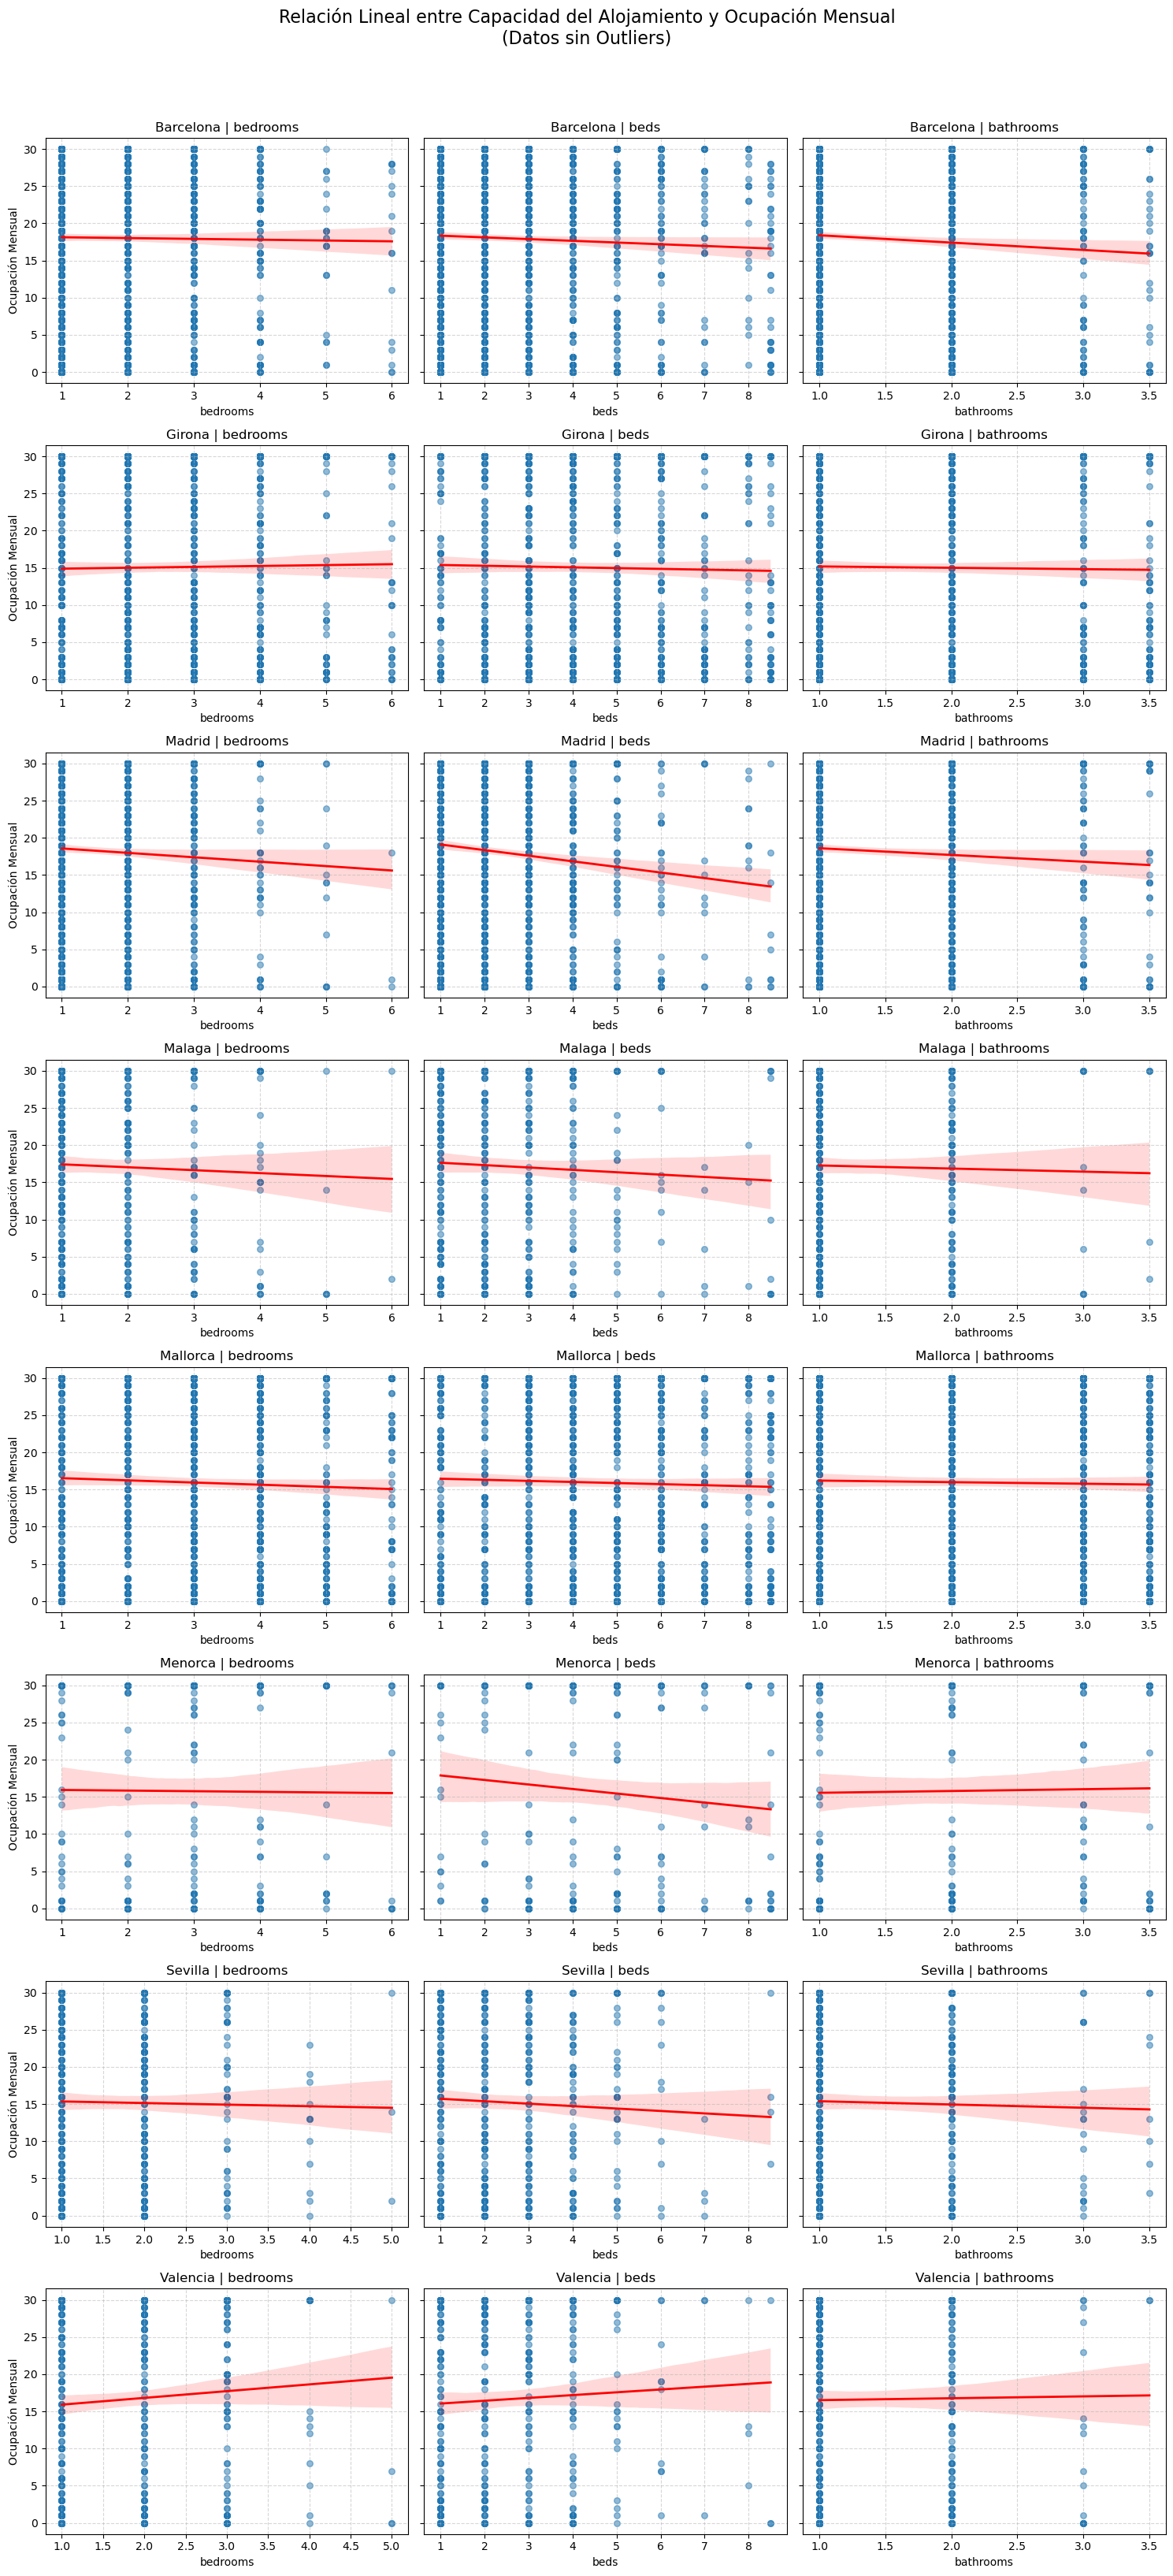

In [60]:
variables_x = ['bedrooms', 'beds', 'bathrooms']
ciudades = sorted(df_sin_outliers['city'].dropna().unique())

fig, axes = plt.subplots(
    nrows=len(ciudades),
    ncols=len(variables_x),
    figsize=(5 * len(variables_x), 4 * len(ciudades)),
    sharey=True
)

# Seguridad para una situación de ciudad única.
if len(ciudades) == 1:
    axes = axes.reshape(1, -1)

for i, ciudad in enumerate(ciudades):
    df_ciudad = df_sin_outliers[df_sin_outliers['city'] == ciudad]

    for j, x_var in enumerate(variables_x):
        ax = axes[i, j]

        sns.regplot(
            x=x_var,
            y='ocupacion_30',
            data=df_ciudad,
            ax=ax,
            scatter_kws={'alpha': 0.5, 's': 30},
            line_kws={'color': 'red', 'lw': 2},
            ci=95
        )

        ax.set_title(f'{ciudad} | {x_var}')
        ax.set_xlabel(x_var)
        ax.set_ylabel('Ocupación Mensual' if j == 0 else '')
        ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle(
    'Relación Lineal entre Capacidad del Alojamiento y Ocupación Mensual\n(Datos sin Outliers)',
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

**Correlación enrte las variables independientes**

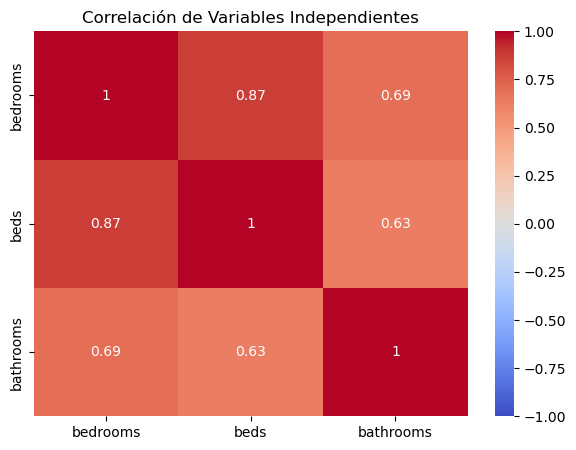

In [61]:
variables_indep = ['bedrooms', 'beds', 'bathrooms']

corr_indep = df_sin_outliers[variables_indep].corr(method='pearson')

plt.figure(figsize=(7, 5))
sns.heatmap(corr_indep, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación de Variables Independientes')
plt.show()

Hay una alta correlacion entre beds y bedrooms. Por tanto existe una alta probabilidad de multicolinealidad

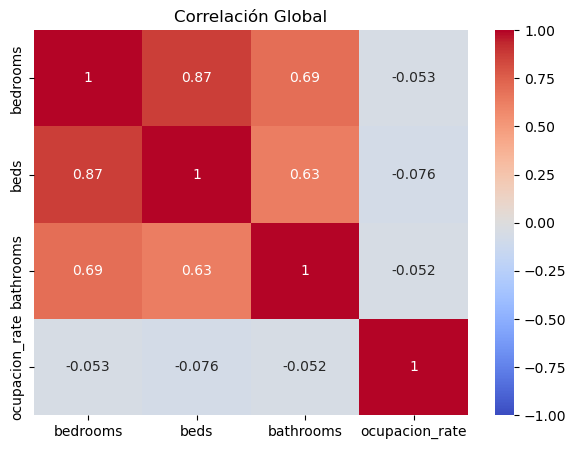

In [62]:
df_sin_outliers['ocupacion_rate'] = (df_sin_outliers['ocupacion_30'] / 30) * 100
variables_corr = ['bedrooms', 'beds', 'bathrooms', 'ocupacion_rate']

corr_global = df_sin_outliers[variables_corr].corr(method='pearson')

plt.figure(figsize=(7, 5))
sns.heatmap(corr_global, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación Global')
plt.show()

In [64]:
resultados_corr = []

for ciudad in df_sin_outliers['city'].unique():
    df_ciudad = df_sin_outliers[df_sin_outliers['city'] == ciudad]

    for var in ['bedrooms', 'beds', 'bathrooms']:
        corr_value = df_ciudad[var].corr(df_ciudad['ocupacion_rate'])

        resultados_corr.append({
            'city': ciudad,
            'variable': var,
            'correlation': corr_value
        })

corr_ciudades = pd.DataFrame(resultados_corr)
corr_ciudades

,city,variable,correlation
0,Malaga,bedrooms,-0.034093
1,Malaga,beds,-0.046674
2,Malaga,bathrooms,-0.019965
3,Madrid,bedrooms,-0.040150
4,Madrid,beds,-0.089502
5,Madrid,bathrooms,-0.046007
6,Sevilla,bedrooms,-0.015602
7,Sevilla,beds,-0.044388
8,Sevilla,bathrooms,-0.024525
9,Barcelona,bedrooms,-0.008834


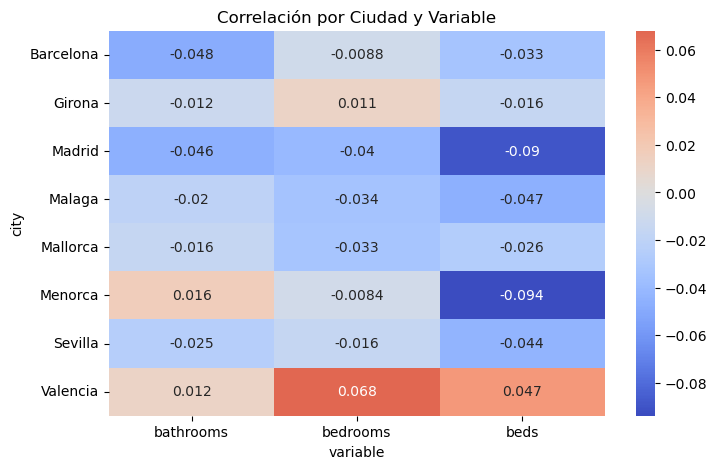

In [65]:
corr_pivot = corr_ciudades.pivot(
    index='city',
    columns='variable',
    values='correlation'
)

plt.figure(figsize=(8, 5))
sns.heatmap(corr_pivot, annot=True, cmap='coolwarm', center=0)
plt.title('Correlación por Ciudad y Variable')
plt.show()

En la mayoría de ciudades españolas, las viviendas grandes no se alquilan tan bien como las pequeñas.

Excepción: Valencia, donde los apartamentos más grandes sí tienen mejor ocupación.

In [54]:
from scipy.stats import pearsonr

significancia = []

for ciudad in df_sin_outliers['city'].unique():
    df_ciudad = df_sin_outliers[df_sin_outliers['city'] == ciudad]

    for var in ['bedrooms', 'beds', 'bathrooms']:
        r, p = pearsonr(df_ciudad[var], df_ciudad['ocupacion_rate'])

        significancia.append({
            'city': ciudad,
            'variable': var,
            'r': r,
            'p_value': p
        })

df_significancia = pd.DataFrame(significancia)
df_significancia

,city,variable,r,p_value
0,Malaga,bedrooms,-0.034093,0.437866
1,Malaga,beds,-0.046674,0.288078
2,Malaga,bathrooms,-0.019965,0.649671
3,Madrid,bedrooms,-0.040150,0.059598
4,Madrid,beds,-0.089502,0.000026
5,Madrid,bathrooms,-0.046007,0.030864
6,Sevilla,bedrooms,-0.015602,0.721598
7,Sevilla,beds,-0.044388,0.310503
8,Sevilla,bathrooms,-0.024525,0.575387
9,Barcelona,bedrooms,-0.008834,0.638840


In [42]:
import statsmodels.api as sm
df_sin_outliers['ocupacion_rate'] = (df_sin_outliers['ocupacion_30'] / 30) * 100
#Variables independientes y dependientes 
X = df_sin_outliers[['beds', 'bedrooms', 'bathrooms']]
y = df_sin_outliers['ocupacion_rate']

# Añadir un término constante
X = sm.add_constant(X)

# Configurar el modelo
model = sm.OLS(y, X).fit()

# Resultados
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         ocupacion_rate   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     23.14
Date:                Thu, 05 Feb 2026   Prob (F-statistic):           6.38e-15
Time:                        20:28:12   Log-Likelihood:                -50905.
No. Observations:               10000   AIC:                         1.018e+05
Df Residuals:                    9996   BIC:                         1.018e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         61.0836      0.906     67.454      0.0

Resumen corto del modelo de regresión

Camas (beds): efecto negativo y significativo
→ Más camas = menor ocupación

Habitaciones (bedrooms): efecto positivo y significativo
→ Más habitaciones = mayor ocupación

Baños (bathrooms): efecto no significativo
→ No influyen claramente en la ocupación

Conclusión:
Las viviendas bien distribuidas (más habitaciones) tienen mejor ocupación, mientras que las viviendas con demasiadas camas tienden a ocuparse menos.


In [45]:
import statsmodels.api as sm
import pandas as pd

resultados = []

for city, sub in df_sin_outliers.groupby('city'):
    X = sub[['bedrooms', 'beds', 'bathrooms']].astype(float)
    X = sm.add_constant(X)

    y = sub['ocupacion_rate'].astype(float)

    model = sm.OLS(y, X).fit(cov_type='HC3')  # Robust SE ✅

    resultados.append({
        'city': city,
        'n_obs': len(sub),
        'r2': model.rsquared,
        'adj_r2': model.rsquared_adj,
        'bedrooms_coef': model.params.get('bedrooms'),
        'beds_coef': model.params.get('beds'),
        'bathrooms_coef': model.params.get('bathrooms'),
        'bedrooms_p': model.pvalues.get('bedrooms'),
        'beds_p': model.pvalues.get('beds'),
        'bathrooms_p': model.pvalues.get('bathrooms')
    })

df_resultados = pd.DataFrame(resultados).sort_values('r2', ascending=False)
df_resultados

,city,n_obs,r2,adj_r2,bedrooms_coef,beds_coef,bathrooms_coef,bedrooms_p,beds_p,bathrooms_p
5,Menorca,224,0.029213,0.015975,6.250339,-6.755932,4.271942,0.213629,0.009770,0.466217
2,Madrid,2202,0.010436,0.009085,3.678703,-3.816470,-1.802041,0.024948,0.000038,0.253888
7,Valencia,528,0.005219,-0.000476,4.079536,-0.401453,-1.817712,0.197371,0.833935,0.621667
0,Barcelona,2825,0.004742,0.003684,3.887698,-2.108432,-3.518716,0.010192,0.011370,0.015829
6,Sevilla,524,0.003038,-0.002714,2.432910,-1.925925,-0.960841,0.461400,0.262541,0.763880
1,Girona,1533,0.002659,0.000702,3.387657,-1.571648,-2.003807,0.054811,0.100641,0.313332
3,Malaga,520,0.002220,-0.003581,0.370297,-1.266268,0.160773,0.908387,0.494799,0.967304
4,Mallorca,1644,0.001400,-0.000426,-1.817447,0.120389,1.272411,0.285058,0.898300,0.492574


In [27]:
df_resultados.to_csv("regression_results_by_city.csv", index=False)

In [57]:
coef_df = df_resultados.melt(
    id_vars='city',
    value_vars=['bedrooms_coef', 'beds_coef', 'bathrooms_coef'],
    var_name='variable',
    value_name='coefficient'
)

coef_df['variable'] = coef_df['variable'].str.replace('_coef', '')

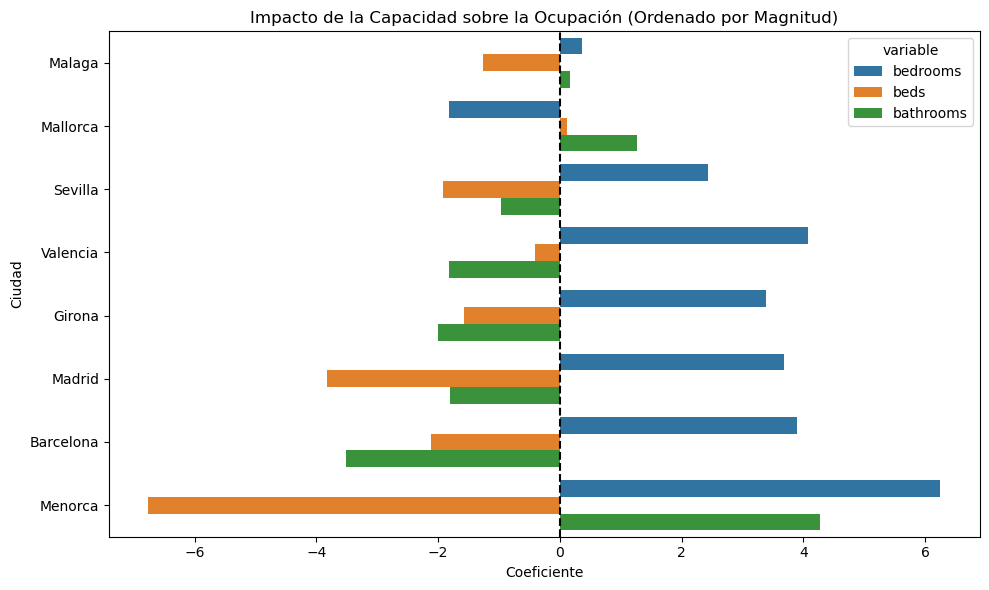

In [36]:
order_cities = (
    coef_df
    .groupby('city')['coefficient']
    .apply(lambda x: x.abs().mean())
    .sort_values()
    .index
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=coef_df,
    y='city',
    x='coefficient',
    hue='variable',
    orient='h',
    order=order_cities
)

plt.axvline(0, color='black', linestyle='--')
plt.title('Impacto de la Capacidad sobre la Ocupación (Ordenado por Magnitud)')
plt.xlabel('Coeficiente')
plt.ylabel('Ciudad')
plt.tight_layout()
plt.show()

 Hallazgos principales
 
🔵 Habitaciones (Bedrooms)

Efecto positivo en todas las ciudades
Impacto más fuerte en: Menorca, Barcelona, Madrid y Valencia

✅ Más habitaciones → mayor ocupación
Indica viviendas mejor distribuidas y más funcionales

🟠 Camas (Beds)

Efecto negativo en todas las ciudades
Impacto negativo más fuerte en: Menorca, Madrid y Barcelona

❌ Más camas → menor ocupación
El exceso de capacidad no coincide con la demanda

🟢 Baños (Bathrooms)

El efecto varía según la ciudad
Menorca y Sevilla: efecto positivo
Barcelona, Madrid, Girona y Valencia: efecto negativo o débil
⚠️ En general, es un factor secundario y poco determinante

C:\Users\esrak\AppData\Local\Temp\ipykernel_3800\1946964987.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


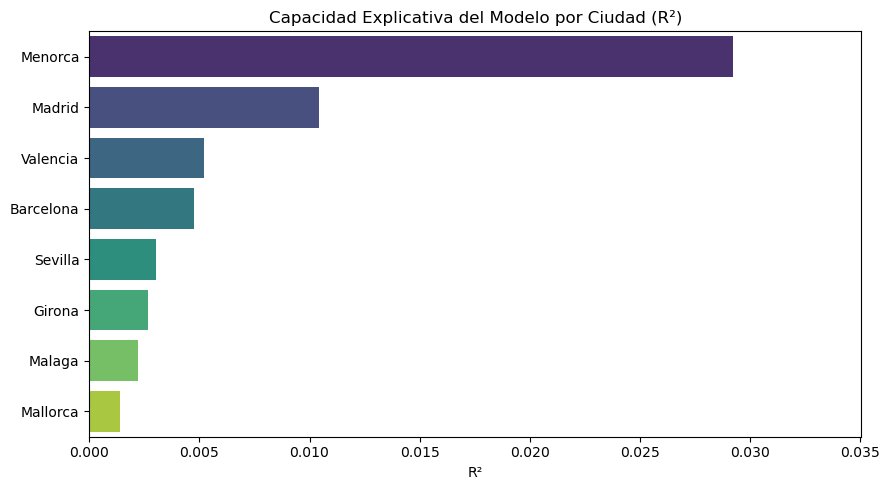

In [46]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df_resultados,
    y='city',
    x='r2',
    palette='viridis',
    orient='h'
)

plt.title('Capacidad Explicativa del Modelo por Ciudad (R²)')
plt.xlabel('R²')
plt.ylabel('')

plt.xlim(0, df_resultados['r2'].max() * 1.2)

plt.tight_layout()
plt.show()

Este gráfico muestra la capacidad explicativa del modelo (R²) por ciudad. En general, los valores de R² son muy bajos, lo que indica que variables como habitaciones, camas y baños explican solo una pequeña parte de la ocupación. Menorca presenta el R² más alto (≈3%), seguida por Madrid (≈1%), mientras que en ciudades como Valencia, Barcelona, Sevilla, Girona, Málaga y Mallorca el poder explicativo del modelo es casi nulo. En conclusión, la ocupación depende principalmente de otros factores no incluidos en el modelo, como el precio, la ubicación o la estacionalidad.

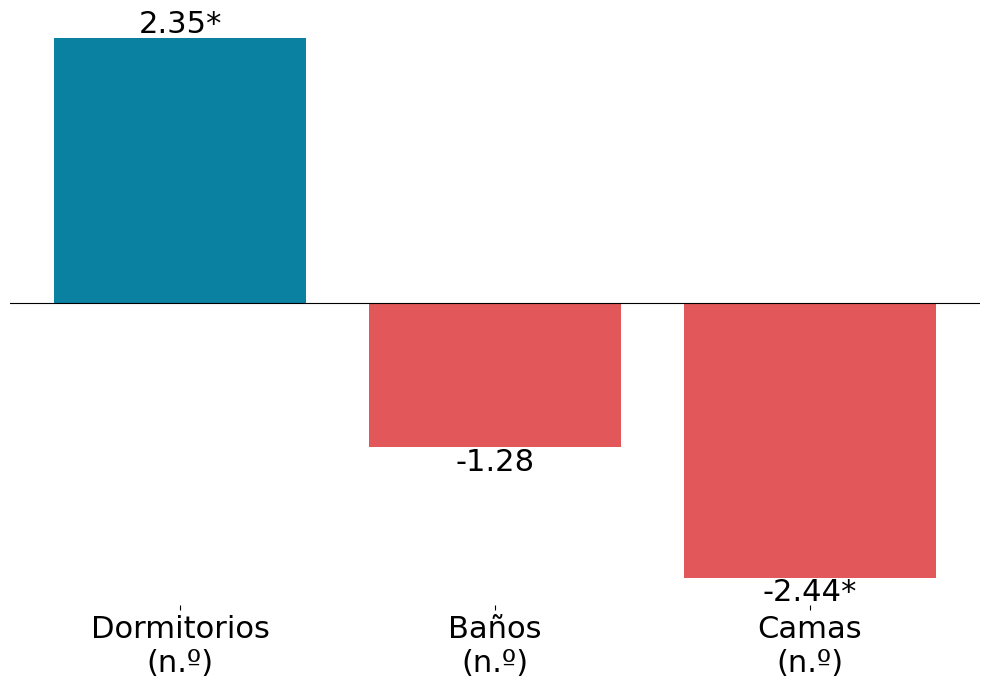

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# 1. Selección de variables (SIN room_type)
cols = [
    'ocupacion_rate',
    'bedrooms',
    'bathrooms',
    'beds'
]

df_clean = df_sin_outliers[cols].dropna()

# 2. Definir variable dependiente (y) e independientes (X)
y = df_clean['ocupacion_rate']
X = df_clean[['bedrooms', 'bathrooms', 'beds']]
X = sm.add_constant(X)

# 3. Regresión OLS
model = sm.OLS(y, X.astype(float)).fit()

# 4. Extraer coeficientes y p-valores
results = pd.DataFrame({
    'predictor': model.params.index,
    'coef': model.params.values,
    'p_value': model.pvalues.values
})

# Eliminar constante para el gráfico
plot_dataset = results[results['predictor'] != 'const'].copy()

# Etiquetas para el gráfico
labels = {
    'bedrooms': 'Dormitorios\n(n.º)',
    'bathrooms': 'Baños\n(n.º)',
    'beds': 'Camas\n(n.º)'
}

plot_dataset['predictor'] = plot_dataset['predictor'].map(labels)

# Color según signo del coeficiente
plot_dataset['color'] = plot_dataset['coef'].apply(
    lambda x: '#0b81a2' if x >= 0 else '#e25759'
)

# 5. Visualización
plt.figure(figsize=(10, 7))
bars = plt.bar(
    plot_dataset['predictor'],
    plot_dataset['coef'],
    color=plot_dataset['color']
)

# Etiquetas sobre las barras
for bar, coef, p_val in zip(bars, plot_dataset['coef'], plot_dataset['p_value']):
    height = bar.get_height()
    label = f"{coef:.2f}"
    if p_val < 0.05:
        label += "*"

    va = 'bottom' if height > 0 else 'top'
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        label,
        ha='center',
        va=va,
        fontsize=22
    )

plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(fontsize=22)
plt.yticks([])
plt.box(False)
plt.tight_layout()
plt.show()

In [49]:
for c in df_sin_outliers['city'].unique():
    print(f"\nCiudad: {c}")
    df_city = df_sin_outliers[df_sin_outliers['city'] == c]

    model = sm.OLS(
        df_city['ocupacion_rate'],
        sm.add_constant(df_city[['bedrooms','bathrooms','beds']])
    ).fit()

    print(model.params)


Ciudad: Malaga
const        59.503890
bedrooms      0.370297
bathrooms     0.160773
beds         -1.266268
dtype: float64

Ciudad: Madrid
const        65.937074
bedrooms      3.678703
bathrooms    -1.802041
beds         -3.816470
dtype: float64

Ciudad: Sevilla
const        52.942186
bedrooms      2.432910
bathrooms    -0.960841
beds         -1.925925
dtype: float64

Ciudad: Barcelona
const        63.462921
bedrooms      3.887698
bathrooms    -3.518716
beds         -2.108432
dtype: float64

Ciudad: Girona
const        51.404053
bedrooms      3.387657
bathrooms    -2.003807
beds         -1.571648
dtype: float64

Ciudad: Valencia
const        51.581928
bedrooms      4.079536
bathrooms    -1.817712
beds         -0.401453
dtype: float64

Ciudad: Mallorca
const        55.289755
bedrooms     -1.817447
bathrooms     1.272411
beds          0.120389
dtype: float64

Ciudad: Menorca
const        56.750750
bedrooms      6.250339
bathrooms     4.271942
beds         -6.755932
dtype: float64


In [19]:
# Ver cuántas propiedades únicas hay por número de habitaciones
distribucion_inventario_bedrooms = df.groupby(['bedrooms'])['unique_id'].nunique()
print(distribucion_inventario_bedrooms)

# Ver cuántas propiedades únicas hay por número de baños
distribucion_inventario_bath = df.groupby(['bathrooms'])['unique_id'].nunique()
print(distribucion_inventario_bath)

# Ver cuántas propiedades únicas hay por número de camas
distribucion_inventario_bed = df.groupby(['beds'])['unique_id'].nunique()
distribucion_inventario_bed

bedrooms
1     4863
2     2380
3     1614
4      768
5      234
6       93
7       17
8       16
9        4
10       3
12       4
14       2
16       1
50       1
Name: unique_id, dtype: int64
bathrooms
1     6049
2     2800
3      681
4      273
5      108
6       45
7       19
8       13
9        5
10       1
11       2
12       3
13       1
Name: unique_id, dtype: int64


beds
1     3216
2     1993
3     1619
4     1211
5      804
6      525
7      235
8      175
9       73
10      65
11       9
12      27
13       5
14       9
15       5
16      15
17       1
18       3
20       2
21       1
22       3
28       2
30       1
50       1
Name: unique_id, dtype: int64

In [21]:
df['ocupacion_media_perc'] = ((30 - df['availability_30']) / 30) * 100

# ¿Cómo afecta el número de habitaciones a la ocupación media?
impacto_habitaciones = df.groupby('bedrooms')['ocupacion_media_perc'].mean()

# ¿Cómo afecta el número de baños a la ocupación media?
impacto_banos = df.groupby('bathrooms')['ocupacion_media_perc'].mean()

impacto_habitaciones, impacto_banos

(bedrooms
 1     58.001234
 2     56.717087
 3     56.011979
 4     53.198785
 5     48.960114
 6     47.777778
 7     23.137255
 8     47.916667
 9     55.833333
 10    85.555556
 12    50.833333
 14    51.666667
 16    70.000000
 50     0.000000
 Name: ocupacion_media_perc, dtype: float64,
 bathrooms
 1     57.877335
 2     56.067857
 3     53.142438
 4     48.791209
 5     48.858025
 6     51.111111
 7     40.175439
 8     65.641026
 9     24.666667
 10     6.666667
 11    70.000000
 12    52.222222
 13     3.333333
 Name: ocupacion_media_perc, dtype: float64)

In [22]:
# Ver cuántas propiedades únicas hay por número de camas
distribucion_inventario = df.groupby(['bedrooms',"city"])['unique_id'].nunique()
distribucion_inventario[distribucion_inventario.index.get_level_values('bedrooms') == 9].head(50)

bedrooms  city    
9         Girona      1
          Malaga      1
          Mallorca    2
Name: unique_id, dtype: int64

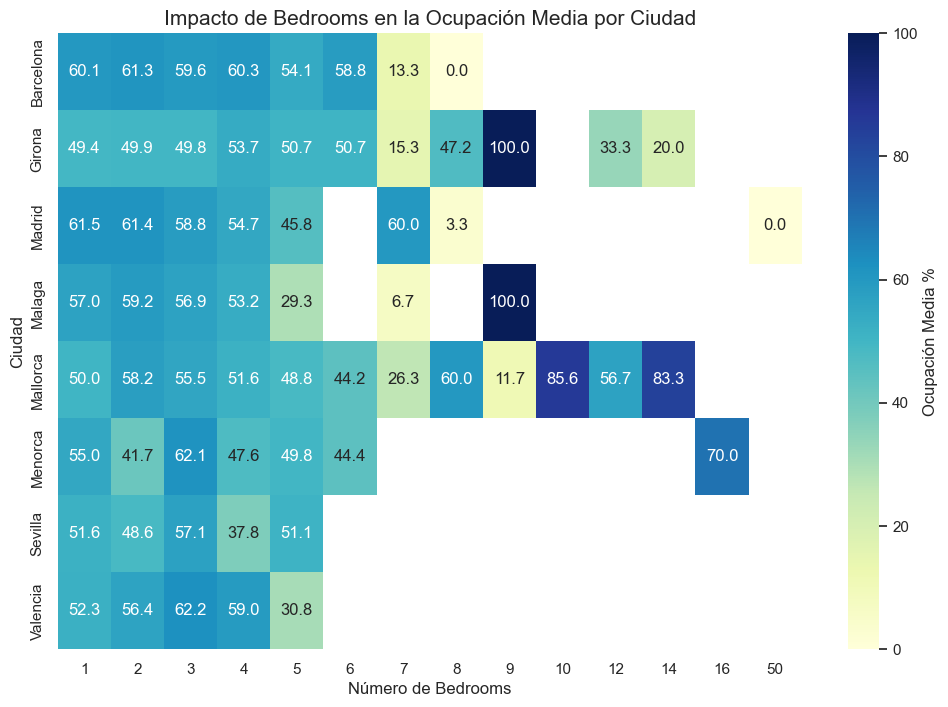

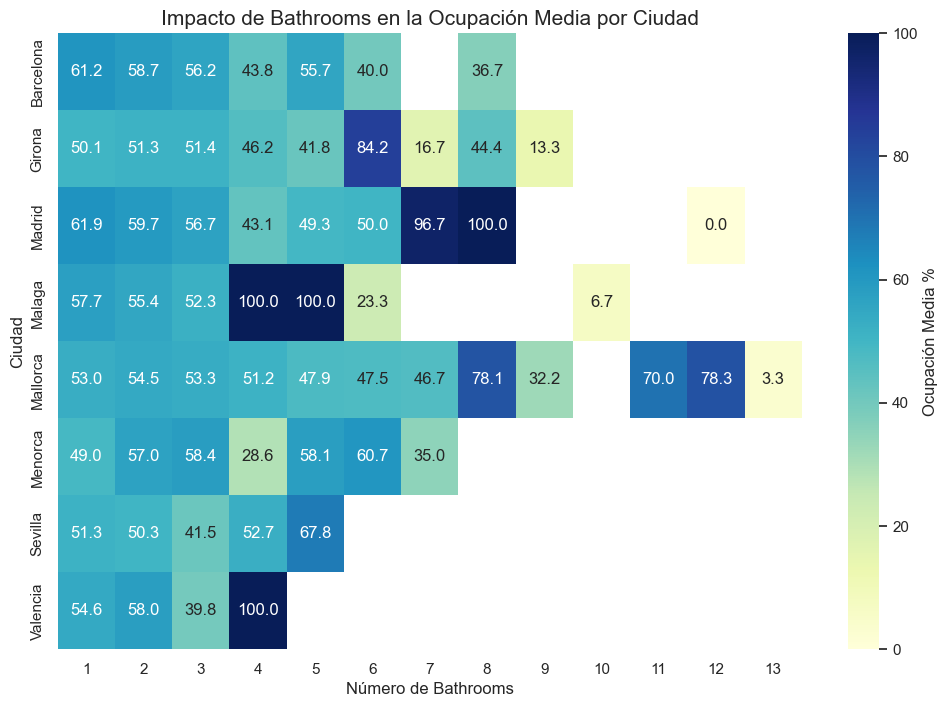

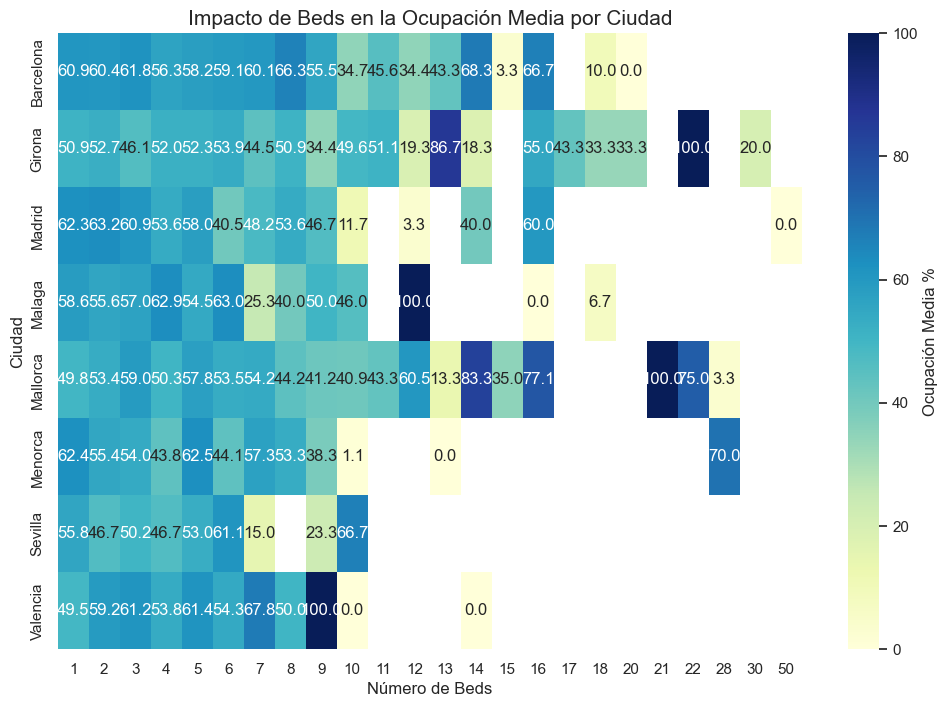

In [23]:
sns.set_theme(style="white")
variables_fisicas = ['bedrooms', 'bathrooms', 'beds']

for var in variables_fisicas:
    # 1. Crear la tabla pivote para la variable actual
    pivot = df.pivot_table(
        index='city', 
        columns=var, 
        values='ocupacion_media_perc', 
        aggfunc='mean'
    ).round(1)
    
    # 2. Configurar el gráfico
    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Ocupación Media %'})
    
    # 3. Personalización
    plt.title(f'Impacto de {var.capitalize()} en la Ocupación Media por Ciudad', fontsize=15)
    plt.xlabel(f'Número de {var.capitalize()}')
    plt.ylabel('Ciudad')
    plt.show()